# Rayleigh-Bénard convection of an isoviscous Stokes fluid

$$
\mathbb{S}_{\textbf{u},p,c}
\begin{cases}
\Omega = [0, \mathcal{A}X] \times [0, X] & \text{aspect ratio } \mathcal{A}=\mathcal{O}(1)\\
c_0(x,y)=1-y+\mathcal{N}(x,y) & \text{perturbed initial linear concentration} \\
c_{\text{D}}(x,y=0)=1 & \text{hot lower boundary} \\
c_{\text{D}}(x,y=X)=0 & \text{cold upper boundary} \\
c_{\text{N}}(x=0,y)=0 & \text{no-flux on left boundary}\\
c_{\text{N}}(x=\mathcal{A}X,y)=0 & \text{no-flux on right boundary}\\
\textbf{u}_{\text{E}}\vert_{\partial\Omega}=\textbf{0} & \text{no-flow on entire boundary}\\
\mathsf{D} = \mathsf{I} & \text{constant isotropic dispersion} \\ 
\mu = 1 & \text{constant viscosity} \\
\rho(c) = -c & \text{linear density} \\
\tau(\mu,\textbf{u})=\tfrac{\mu}{2}(\nabla\textbf{u} + (\nabla\textbf{u})^{\mathsf{T}}) & \text{Newtonian stress} \\
\textbf{e}_g=-\textbf{e}_y & \text{vertically downward gravity}\\ 
\end{cases}
$$

In [1]:
from lucifex.sim import run
from lucifex.utils.npy_utils import as_index
from lucifex.solver import maximum
from lucifex.plt import plot_colormap, plot_line, create_animation, save_figure, display_animation
from py.C21_stokes_convection import stokes_rayleigh_benard_rectangle

simulation = stokes_rayleigh_benard_rectangle(
    aspect=2.0,  
    Nx=64,
    Ny=64,
    cell='quadrilateral',
    scaling='diffusive',
    Ra=5e4,
    c_ampl=1e-3,
    c_freq=(16, 8),
    dt_max=0.1, 
)

n_stop = 200
dt_init = 1e-6
n_init = 10
run(simulation, n_stop=n_stop, dt_init=dt_init, n_init=n_init)

c, u, p, up = simulation['c', 'u', 'p', 'up']

In [2]:
time_slice = slice(0, None, 2)
titles = [f'$c(t={t:.3f})$' for t in c.time_series[time_slice]]

anim = create_animation(
    plot_colormap,
    colorbar=False,
)(c.series[time_slice], title=titles)
anim_path = save_figure(f'{c.name}(x,y,t)', return_path=True)(anim)

display_animation(anim_path)

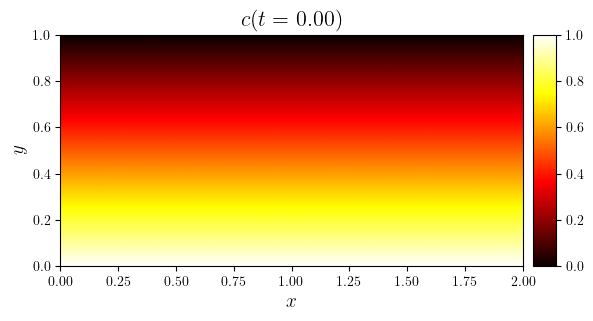

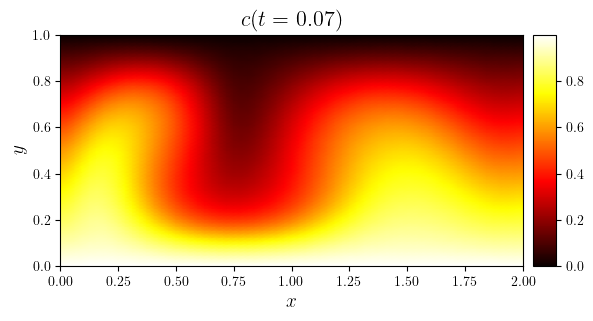

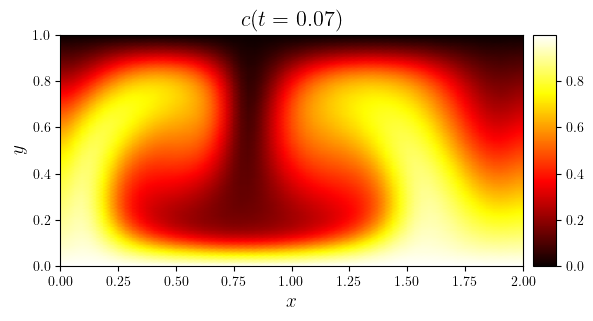

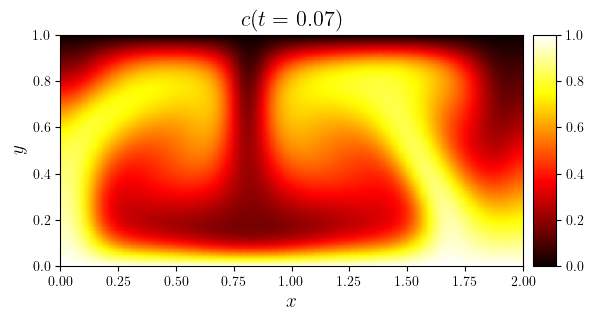

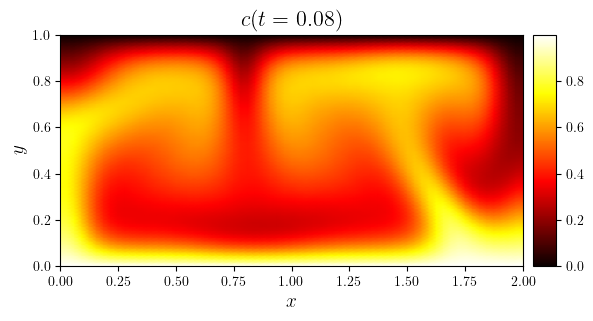

In [3]:
time_indices = as_index(c.time_series, (0, 0.25, 0.5, 0.75, -1), fraction=True)
for i in time_indices:
    t = c.time_series[i]
    fig, ax = plot_colormap(c.series[i], title=f'$c(t={t:.2f})$')
    save_figure(f'c(x,y,t={c.time_series[i]:.3f})', thumbnail=(i == -1))(fig)

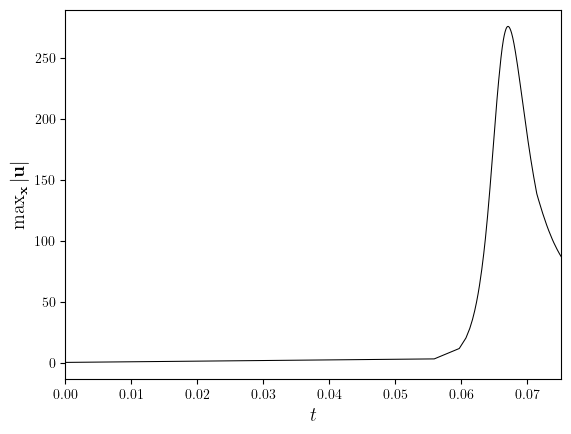

In [4]:
u_max = [maximum(i) for i in u.series]
fig, ax = plot_line((u.time_series, u_max), x_label='$t$', y_label='$\max_{\mathbf{x}}|\mathbf{u}|$')
save_figure(f'uMax(t)')(fig)